In [10]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

from demos.ControlledPendulum.src.master_pendulum.components import (
    FMUPendulum, OpenSimPendulum, FEMPendulum
)
from demos.ControlledPendulum.scripts.torque_profiles import (
    constant_torque, ramp_torque, zero_torque
)
from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config
from thesis.notebooks.plot_setup import set_professional_style
plt = set_professional_style()

from syssimx import Connection, System
from syssimx.system.connection import EventConnection
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

In [11]:
mesh_params = config.MeshParameters()

geo_params = config.GeometryParameters()
h_max = geo_params.r_rod / 3

mesh_params = config.MeshParameters()
mesh_params.max_element_size = h_max

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = np.rad2deg(0.0) # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 0 # Nm

mat_params = config.MaterialParameters()

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1.5
sim_params.with_contact = False
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e10

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'mesh_params': mesh_params,
    'mat_params': mat_params,
    'contact_params': contact_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
    'mesh_params': mesh_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")

pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)

t = 0.0
dt = pendulum.fem.sim_params.tau
t_end = pendulum.fem.sim_params.t_end

In [12]:
pendulum.setup_monitoring()
pendulum.display_monitoring()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [13]:
from syssimx import FMUComponent

if sys.platform.startswith("linux"):
    fmu_path = f'demos/ControlledPendulum/artifacts/fmus/linux/Plants/Pendulum_cvode.fmu'
elif sys.platform.startswith("win"):
    fmu_path = f'C:\\Users\\flori\\source\\repos\\FlorianFrech\\SystemSimulation\\demos\\ControlledPendulum\\artifacts\\fmus\\win32\\Plants\\Pendulum_cvode.fmu'

fmu = FMUComponent(name="FMU_Pendulum",fmu_path=fmu_path, group="Plant")

parameters = fmu.get_parameters()
parameters['L'] = pendulum.fem._equivalent_length
parameters['m'] = pendulum.fem.mass
parameters['J'] = pendulum.fem.inertia
parameters['theta_start'] = np.deg2rad(init_params.angular_position_deg)
fmu.set_parameters(**parameters)

fmu.initialize(0.0)

In [14]:
while t < t_end:
    # 1) Compute input torque
    # torque = torque_func(t)

    # 2) Perform simulation step
    pendulum.set_inputs({"tau": 1}, t=t)
    fmu.set_inputs({"tau": 1}, t=t)

    # 3) Integrate one time step
    pendulum.do_step(t, dt)
    fmu.do_step(t, dt)

    # 4) Advance time
    t += dt

In [15]:
t_vals = {mode: [] for mode in pendulum.models.keys()}
torque_vals = {mode: [] for mode in pendulum.models.keys()}
alpha_vals = {mode: [] for mode in pendulum.models.keys()}
omega_vals = {mode: [] for mode in pendulum.models.keys()}
q_vals = {mode: [] for mode in pendulum.models.keys()}

for mode in pendulum.models.keys():
    t_vals[mode], res_dict = pendulum.models[mode].get_history_arrays()
    alpha_vals[mode] = res_dict["alpha"]
    omega_vals[mode] = res_dict["omega"]
    q_vals[mode] = res_dict["theta"]

In [16]:
ref = fmu.get_history()
t_an_vals = ref["theta"]["time"]
theta_an_vals = ref["theta"]["values"]
omega_an_vals = ref["omega"]["values"]
alpha_an_vals = ref["alpha"]["values"]

In [17]:
marker_size = 3
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "FEM",
}
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "OpenSim",
}  # Green
eqb_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
    "label": "FMU",
}  # Purple

styles = {
    "FEM": fem_style,
    "OpenSim": opensim_style,
    "FMU": eqb_style,
}

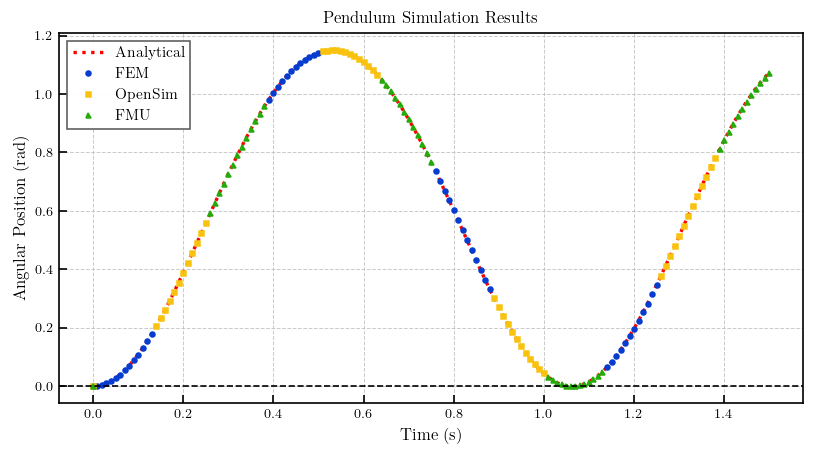

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(t_an_vals, theta_an_vals, color='red', linestyle=':', linewidth=2, label="Analytical")
for mode in pendulum.models.keys():
    plt.plot(t_vals[mode], q_vals[mode], **styles[mode])
plt.axhline(y=0, color='k', linestyle='--', linewidth=1)  # Add horizontal line at y=0
plt.xlabel("Time (s)")
plt.ylabel("Angular Position (rad)")
plt.title("Pendulum Simulation Results")
plt.legend()
plt.grid()
plt.show()  